In [3]:
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True)

from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=808).fit(X, y)

i:\OC\P3\projet3\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
clf.predict([X[8, :]])

array([0])

In [5]:
clf.predict([X[13, :]])

array([1])

In [6]:

clf.predict_proba([X[8, :]])

array([[0.68866793, 0.31133207]])

In [7]:
clf.predict_proba([X[13, :]])

array([[0.12496982, 0.87503018]])

<Axes: ylabel='Count'>

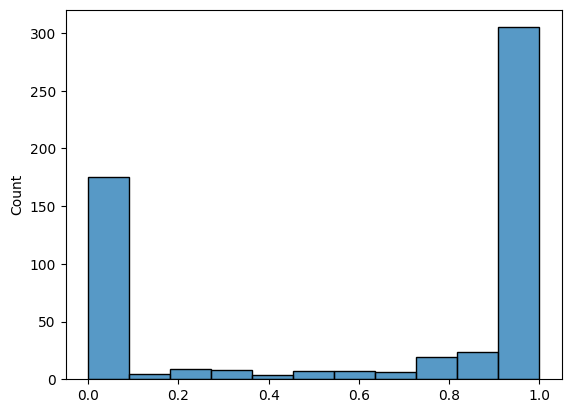

In [8]:
y_hat_proba = clf.predict_proba(X)[:,1]
import seaborn as sns
sns.histplot(y_hat_proba)

In [9]:
y_pred = clf.predict(X)

In [10]:
from sklearn.metrics import accuracy_score
accuracy_score(y, y_pred)

0.9472759226713533

In [11]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y, y_pred)


array([[193,  19],
       [ 11, 346]])

In [ ]:
y_hat_proba = clf.predict_proba(X)[:,1]

In [13]:
y_pred_03 = [ 0 if value < 0.3 else 1 for value in y_hat_proba ]
y_pred_07 = [ 0 if value < 0.7 else 1 for value in y_hat_proba ]

In [14]:
confusion_matrix(y, y_pred_03)


array([[186,  26],
       [  6, 351]])

In [15]:
confusion_matrix(y, y_pred_07)


array([[200,  12],
       [ 18, 339]])

In [16]:
from sklearn.metrics import precision_score, recall_score
precision_score(y, y_pred)
recall_score(y, y_pred)

0.969187675070028

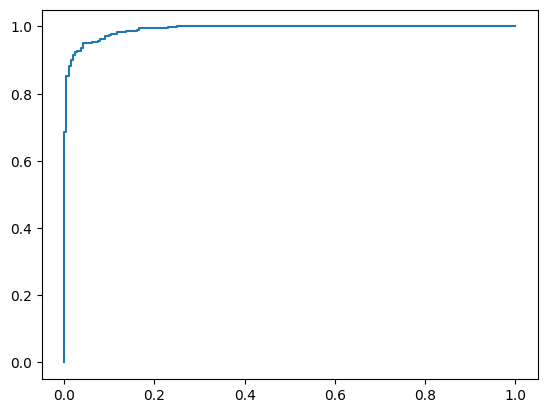

In [17]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y, y_hat_proba)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr)